<a href="https://colab.research.google.com/github/majshal/-dobre-PUM/blob/regresja/01_04_pum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [3]:
# 1. Sprawdź liczbę wszystkich przypadków
print(f'Liczba wszystkich przypadków: {df.shape[0]}')

Liczba wszystkich przypadków: 569


In [4]:
# 2. Sprawdź liczbę przypadków raka złośliwego
malignant_count = (y == 0).sum()
print(f'Liczba przypadków raka złośliwego: {malignant_count}')

Liczba przypadków raka złośliwego: 212


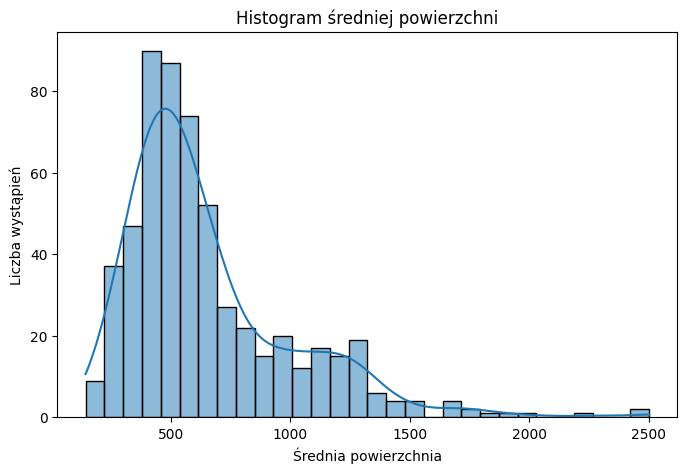

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
sns.histplot(df['mean area'], bins=30, kde=True)
plt.title('Histogram średniej powierzchni')
plt.xlabel('Średnia powierzchnia')
plt.ylabel('Liczba wystąpień')
plt.show()


Liczba wszystkich przypadków: 569
Liczba przypadków raka złośliwego: 212


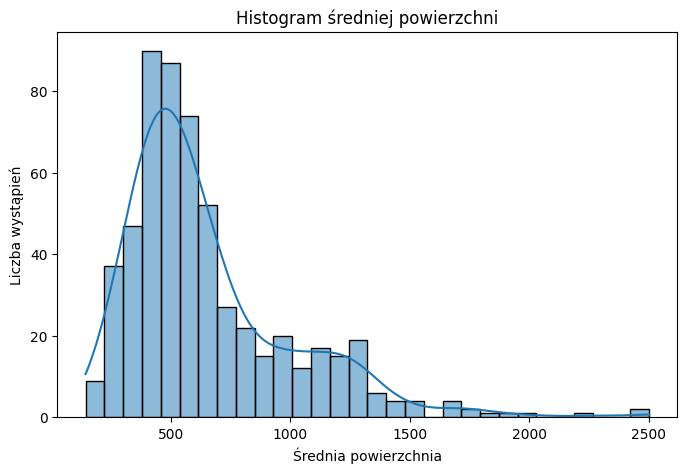

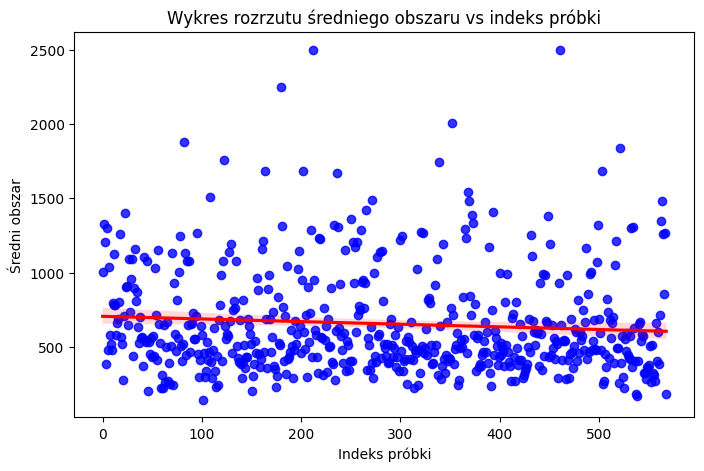

In [10]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
#

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f'Liczba wszystkich przypadków: {df.shape[0]}')

malignant_count = (y == 0).sum()
print(f'Liczba przypadków raka złośliwego: {malignant_count}')
plt.figure(figsize=(8, 5))
sns.histplot(df['mean area'], bins=30, kde=True)
plt.title('Histogram średniej powierzchni')
plt.xlabel('Średnia powierzchnia')
plt.ylabel('Liczba wystąpień')
plt.show()


plt.figure(figsize=(8, 5))
sns.regplot(x=df.index, y=df['mean area'], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('Wykres rozrzutu średniego obszaru vs indeks próbki')
plt.xlabel('Indeks próbki')
plt.ylabel('Średni obszar')

plt.show()


Total number of cases: 569
Number of malignant cases: 212


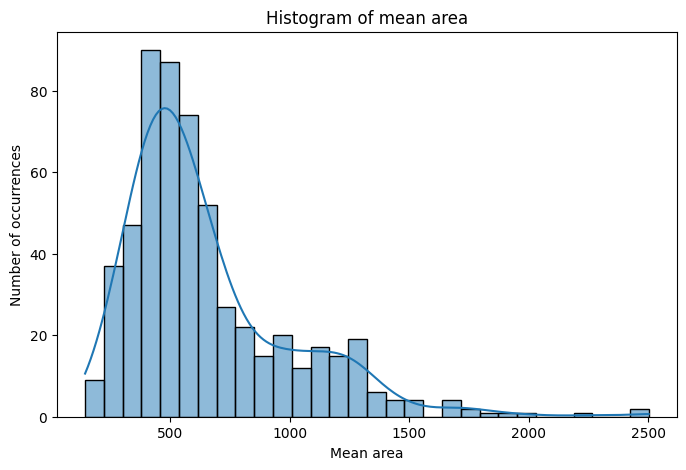

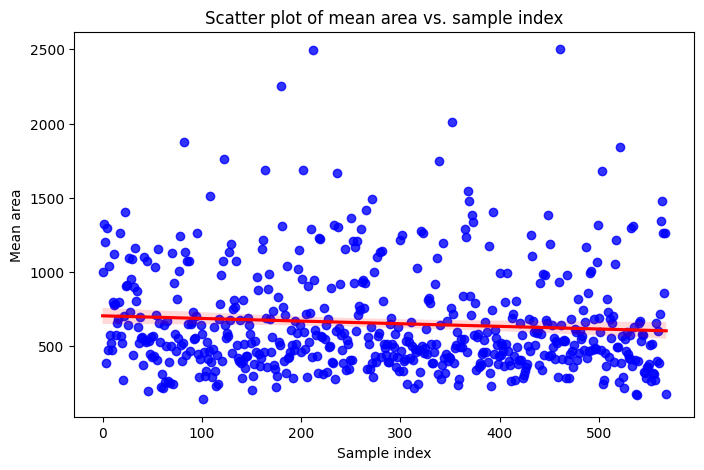

Confusion Matrix:
 [[39  4]
 [ 1 70]]


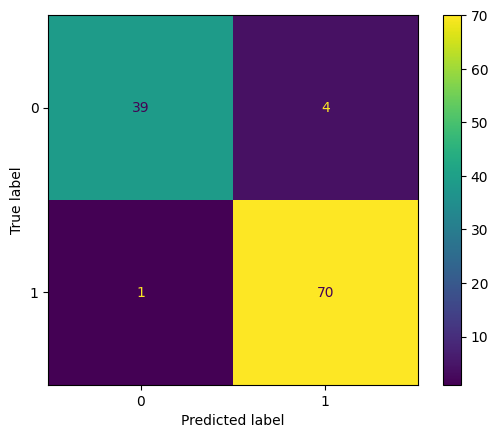

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f'Total number of cases: {df.shape[0]}')

malignant_count = (y == 0).sum()
print(f'Number of malignant cases: {malignant_count}')

plt.figure(figsize=(8, 5))
sns.histplot(df['mean area'], bins=30, kde=True)
plt.title('Histogram of mean area')
plt.xlabel('Mean area')
plt.ylabel('Number of occurrences')
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(x=df.index, y=df['mean area'], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('Scatter plot of mean area vs. sample index')
plt.xlabel('Sample index')
plt.ylabel('Mean area')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(random_state=42, max_iter=10000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

print(classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


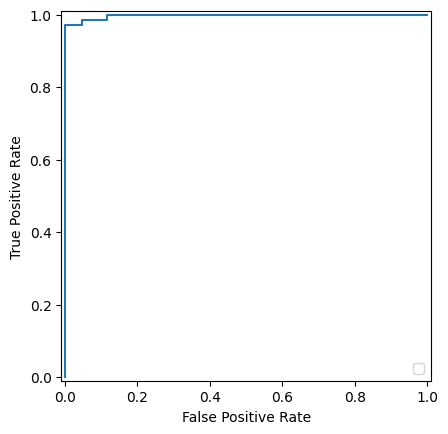

In [8]:
from sklearn.metrics import RocCurveDisplay, roc_curve

y_score = clf.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=clf.classes_[1])
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
plt.show()